# 00 — Dark Matter Halo Prerequisites

Generic large-scale-structure ingredients used by both `01_hi_model.ipynb`
(neutral hydrogen) and `02_dm_model.ipynb` (DM annihilation). Nothing here
is HI- or gamma-specific — this notebook builds up the halo-model
machinery from the linear matter power spectrum to the NFW Fourier
transform.

**Pipeline:** $P_\mathrm{lin}(k,z) \to \sigma(M,z) \to \nu(M,z) \to dn/dM \to b(M)$
$\to \Delta_\mathrm{vir}(z) \to R_\mathrm{vir}(M,z) \to c_\mathrm{vir}(M,z) \to \rho_\mathrm{NFW}(r) \to \tilde u_\mathrm{NFW}(k\mid M)$.

**References:**

1. Sheth & Tormen (1999)
2. Sheth, Mo & Tormen (2001)
3. Bryan & Norman (1998)
4. Correa et al. (2015) Appendix B1
5. Navarro, Frenk & White (1997)

See `docs/literature/` for one-page summaries.

In [ ]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import halo_model as hm, hmf_interface as hmfi
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print('Pipeline initialized.')

Pipeline initialized.


## 0. Linear Perturbation Theory — Prelude

### 0.1 Starting points & what we study

Cosmological structure formation starts from a homogeneous, isotropic
FLRW background with scale factor $a(t)$ and Hubble rate
$H(t)=\dot a/a$, on top of which small inhomogeneities grow under
gravity. The object we want to model is the **matter density contrast**

$$\delta(\mathbf{x},t) = \frac{\rho(\mathbf{x},t)-\bar\rho(t)}{\bar\rho(t)},$$

a dimensionless, zero-mean random field whose two-point statistics are
encoded in the power spectrum $P(k,z)$ introduced in §1.

Three physical conditions shape the regime relevant to halo formation.
First, the scales of interest are deep **sub-horizon**, satisfying
$k \gg aH/c$, where the Newtonian limit of GR reproduces the
relativistic result up to gauge corrections that vanish on sub-horizon
scales. Second, we work **post-recombination** ($z\lesssim 1100$):
photons have decoupled from baryons, radiation pressure no longer
supports baryonic perturbations, and the baryonic Jeans scale moves to
very small scales — for the halo-mass range we care about
($M\gtrsim 10^6\,M_\odot/h$) we are firmly above it. Third, **only
matter clusters**: dark energy (a cosmological constant) is spatially
uniform by construction, $\delta_\Lambda\equiv 0$, so it contributes to
$\bar\rho$ but not to $\rho-\bar\rho$ and drops out of Poisson's source
term — this remains true even today, when $\Omega_\Lambda$ dominates
the *background*. Post-recombination radiation is free-streaming and
its contrast on sub-horizon scales is heavily suppressed, so it too is
negligible as a source. What $\Lambda$ *does* affect is the expansion
rate $H(z)$ and hence the friction term $2H\dot\delta$ — captured by
$D(z)$ in §0.5.

Together these justify adopting the **Newtonian, sub-horizon,
single-stream** description for the rest of this section. Beyond this
regime — super-horizon scales, the radiation era, or
post-shell-crossing dynamics — one needs the full GR Boltzmann
hierarchy (handled by CAMB upstream of this notebook) or N-body
simulation.

### 0.2 Physical model: fluid + Poisson equations

Treat matter as a self-gravitating pressureless fluid in the expanding
background. In comoving coordinates $\mathbf{x}=\mathbf{r}/a(t)$ with
peculiar velocity $\mathbf{v}=a\dot{\mathbf{x}}$, and with $\partial_t$
taken at fixed $\mathbf{x}$, the governing equations are

$$\frac{\partial\rho}{\partial t} + 3H\rho + \frac{1}{a}\nabla\!\cdot\!(\rho\mathbf{v}) = 0
\qquad\text{(continuity)}$$

$$\frac{\partial\mathbf{v}}{\partial t} + H\mathbf{v}
+ \frac{1}{a}(\mathbf{v}\!\cdot\!\nabla)\mathbf{v}
= -\frac{1}{a}\nabla\Phi
\qquad\text{(Euler, $p=0$)}$$

$$\nabla^2\Phi = 4\pi G\,a^2\,(\rho-\bar\rho)
\qquad\text{(Poisson)}$$

The $3H\rho$ term in continuity is the dilution of proper density under
expansion; the $H\mathbf{v}$ term in Euler is the corresponding Hubble
drag on peculiar velocities. $\Phi$ is the peculiar gravitational
potential sourced by density *contrasts*, not the mean. Here $\rho$
denotes cold dark matter, or the total matter $\rho_c+\rho_b$ on scales
above the baryonic Jeans length where baryons fall into CDM potential
wells as if pressureless and share a common $\delta_m$ with CDM.

### 0.3 Linearisation for $|\delta|\ll 1$

Write $\rho = \bar\rho(t)\,[1+\delta(\mathbf{x},t)]$ and assume both
$\delta$ and $\mathbf{v}$ are small. Substituting and keeping only terms
linear in the perturbations:

- **Continuity** — at zeroth order $\dot{\bar\rho} + 3H\bar\rho = 0$ (i.e. $\bar\rho\propto a^{-3}$); at first order, after subtracting the background,
$$\dot\delta + \frac{1}{a}\nabla\!\cdot\!\mathbf{v} = 0.$$
- **Euler** — the advection term $(\mathbf{v}\!\cdot\!\nabla)\mathbf{v}$ is second order and drops out:
$$\dot{\mathbf{v}} + H\mathbf{v} = -\frac{1}{a}\nabla\Phi.$$
- **Poisson** — already linear:
$$\nabla^2\Phi = 4\pi G\,a^2\,\bar\rho_m\,\delta.$$

Take $\partial_t$ of the linearised continuity equation, use Euler to
eliminate $\dot{\mathbf{v}}$, and Poisson to eliminate $\Phi$. The
divergence of the velocity field cancels out, leaving a closed equation
for $\delta$ alone:

$$\boxed{\;\ddot\delta + 2H\dot\delta - 4\pi G\bar\rho_m\,\delta = 0.\;}$$

Crucially, **no spatial gradients of $\delta$ appear** — pressureless
matter has no Jeans scale, so the equation is local in $\mathbf{x}$ and
identical for every point.

### 0.4 Fourier decoupling

Expand $\delta(\mathbf{x},t) = \int\!\frac{d^3k}{(2\pi)^3}\,
\tilde\delta_\mathbf{k}(t)\,e^{i\mathbf{k}\cdot\mathbf{x}}$. Because the
linearised equation has no $\nabla\delta$ terms, each Fourier coefficient
satisfies the *same* ODE independently:

$$\ddot{\tilde\delta}_\mathbf{k} + 2H(t)\,\dot{\tilde\delta}_\mathbf{k}
- 4\pi G\bar\rho_m(t)\,\tilde\delta_\mathbf{k} = 0.$$

Modes do not mix, and the equation is **scale-independent**: the time
evolution is the same for every $|\mathbf{k}|$.

### 0.5 The linear growth factor $D(z)$

Scale-independence means we can factor the time and space dependence:

$$\tilde\delta_\mathbf{k}(t) = D(t)\,\tilde\delta_\mathbf{k}(t_0),$$

where $D(t)$ is the growing solution of the same ODE (a decaying mode
exists but is irrelevant on observational timescales), conventionally
normalised to $D(z=0)=1$. Two consequences underpin everything that
follows:

1. **Shape is frozen.** The full density field rescales coherently,
   $\delta(\mathbf{x},z) = D(z)\,\delta(\mathbf{x},0)$, so the linear
   power spectrum scales as $P_\mathrm{lin}(k,z) = D^2(z)\,P_\mathrm{lin}(k,0)$.
2. **Gaussianity is preserved.** A linear, mode-by-mode rescaling of
   Gaussian initial conditions stays Gaussian — the two-point function
   $P(k,z)$ fully specifies the statistics.

Linear theory breaks down once $\delta\sim 1$, which happens first on
small scales and late times ($k\gtrsim 0.1\,h/\mathrm{Mpc}$ at $z=0$).
Beyond that regime we move to the halo model (Sections 3–9), which
stitches non-linear collapsed objects on top of the linear backbone
introduced next.

## 1. Linear Matter Power Spectrum $P_\mathrm{lin}(k,z)$

The **linear matter power spectrum** describes the variance of matter
density fluctuations $\delta(\mathbf{x},z) = (\rho-\bar\rho)/\bar\rho$ as a
function of comoving wavenumber $k$, in the regime where perturbations
remain small ($|\delta|\ll 1$) and evolve according to linear perturbation
theory.

### Definition

In Fourier space, statistical homogeneity and isotropy imply

$$\langle \tilde\delta(\mathbf{k},z)\,\tilde\delta^*(\mathbf{k}',z)\rangle
= (2\pi)^3\,P(k,z)\,\delta_D^3(\mathbf{k}-\mathbf{k}').$$

### Structure

$$P_\mathrm{lin}(k,z) = A_s\,k^{n_s}\,T^2(k)\,D^2(z),$$

- **Primordial tilt** $k^{n_s}$ — near scale-invariant ($n_s\approx 0.965$) from inflation.
- **Transfer function** $T(k)$ — encodes sub-horizon processing: radiation-era suppression on small scales (turnover at $k_\mathrm{eq}$), baryon acoustic oscillations, and free-streaming effects.
- **Growth factor** $D(z)$ — scale-independent in linear theory for $\Lambda$CDM, normalised to $D(0)=1$:

$$P_\mathrm{lin}(k,z) = D^2(z)\,P_\mathrm{lin}(k,0).$$

### Limits of validity

Linear theory holds for $k\lesssim 0.1\,h/\mathrm{Mpc}$ at $z=0$; beyond
this, mode coupling drives non-linear corrections (HALOFIT, HMcode, or
N-body calibration required).

### Role in this pipeline

Generated by CAMB at the Planck 2018 cosmology. Everything downstream
(mass variance, halo mass function, bias, 3D and 2D power spectra) is a
functional of $P_\mathrm{lin}$; it is the backbone input from which the
HI and DM-halo spectra are built and projected through window functions
into the angular spectrum $C_\ell$.

Units: $k$ in $h/\mathrm{Mpc}$, $P$ in $(\mathrm{Mpc}/h)^3$.

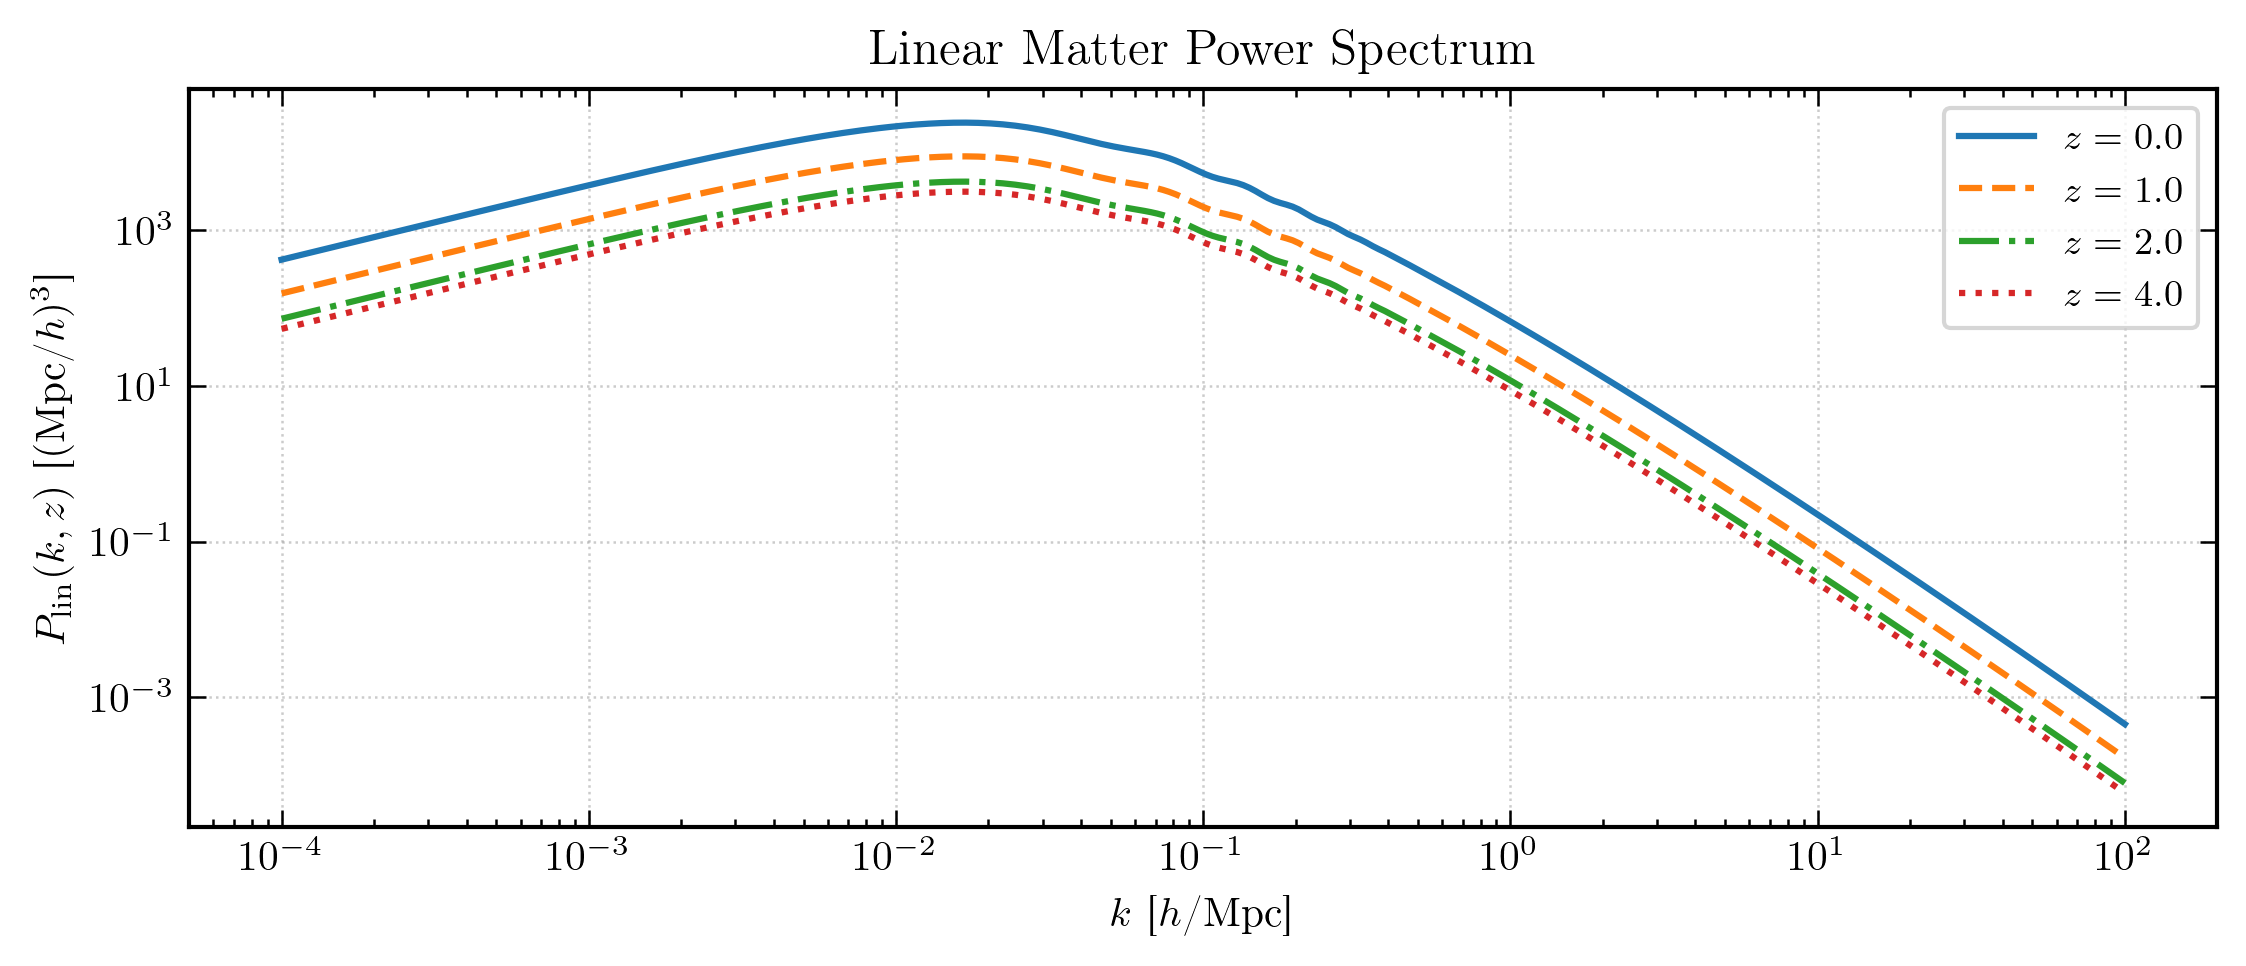

In [ ]:
k_arr = np.logspace(-4, 2, 300)
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0.0, '-'), (1.0, '--'), (2.0, '-.'), (4.0, ':')]:
    P = cosmo.P_lin(k_arr, z)
    ax.loglog(k_arr, P, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$P_\mathrm{lin}(k,z)$ [(Mpc/$h$)$^3$]')
ax.set_title('Linear Matter Power Spectrum'); ax.legend(); fig.tight_layout()

## 2. Linear Growth Factor $D(z)$ and Hubble Rate

The growing solution of the linear equation in §0.5 admits the closed
form (Heath 1977; Carroll, Press & Turner 1992)

$$D_1(z) \;\propto\; E(z)\!\int_z^\infty \frac{(1+z')\,dz'}{E^3(z')},$$

with $E(z) = H(z)/H_0 = \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$ in flat
$\Lambda$CDM. The proportionality constant is conventional — we adopt
$D(z) = D_1(z)/D_1(0)$, so that $D(0)=1$ (this is what `cosmo.growth_factor`
returns). $D(z)$ controls how linear-theory amplitudes scale with
redshift; the halo mass function inherits this scaling through $\sigma(M,z)$.

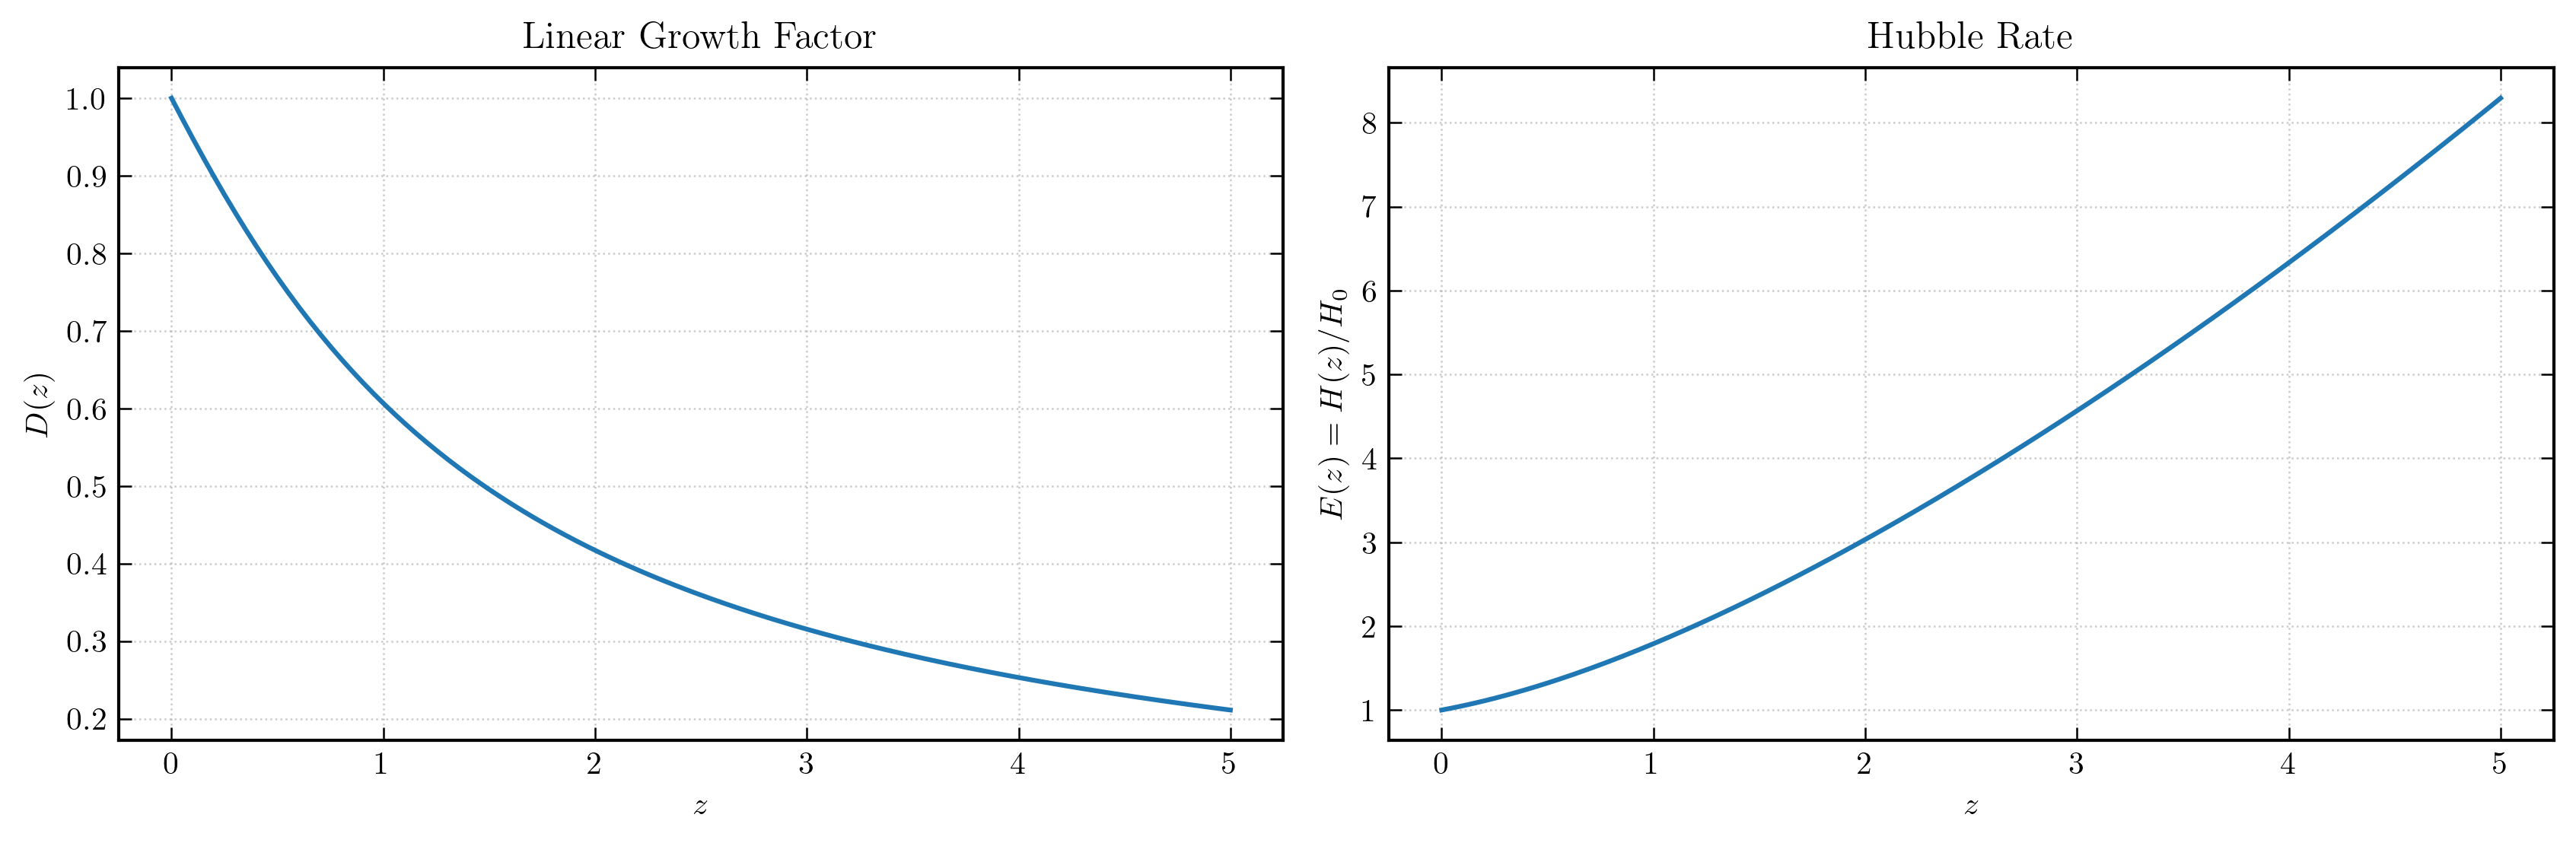

In [ ]:
z_arr = np.linspace(0.0, 5.0, 200)
D = np.array([cosmo.growth_factor(z) for z in z_arr])
E = np.array([cosmo.E(z) for z in z_arr])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
ax1.plot(z_arr, D, lw=sty.LW_STANDARD)
ax1.set_xlabel('$z$'); ax1.set_ylabel('$D(z)$'); ax1.set_title('Linear Growth Factor')
ax2.plot(z_arr, E, lw=sty.LW_STANDARD)
ax2.set_xlabel('$z$'); ax2.set_ylabel(r'$E(z) = H(z)/H_0$'); ax2.set_title('Hubble Rate')
fig.tight_layout()

## 3. Mass Variance $\sigma(M,z)$ and Peak Height $\nu(M,z)$

$$\sigma^2(R,z) = \int_0^\infty \frac{dk}{2\pi^2}\,k^2\,P_\mathrm{lin}(k,z)\,W_R^2(k)$$

with the top-hat window $W_R(k) = 3\,[\sin(kR)-kR\cos(kR)]/(kR)^3$ and
$M = (4\pi/3)\,R^3\,\bar\rho_m^\mathrm{com}$. The peak height
$\nu(M,z) = \delta_c/\sigma(M,z)$ with $\delta_c=1.686$ measures how
rare a halo of mass $M$ is at redshift $z$. Massive/late = rare = high $\nu$.

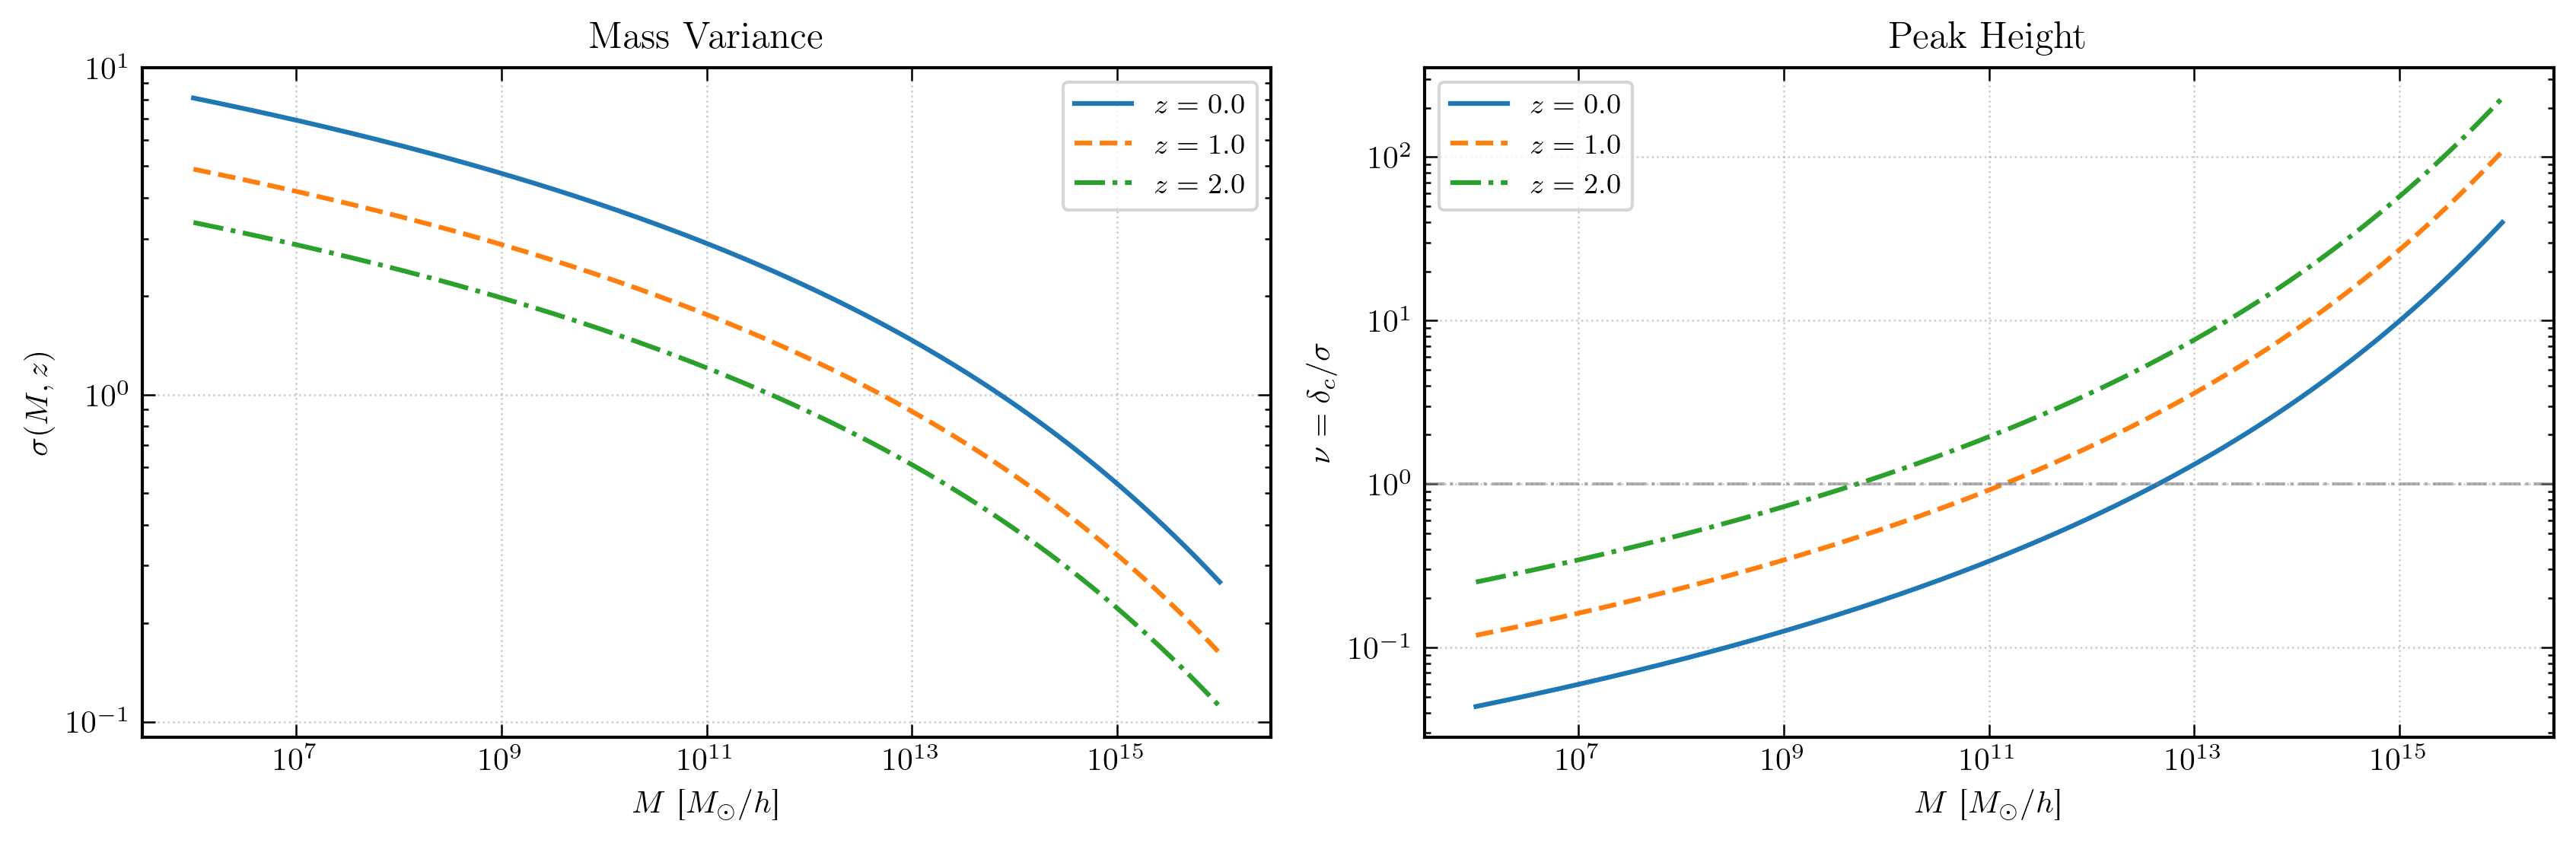

In [ ]:
M_arr = np.logspace(6, 16, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
for z, ls in [(0.0, '-'), (1.0, '--'), (2.0, '-.')]:
    sig = np.array([hmfi.sigma(M, z) for M in M_arr])
    nu = np.array([hm.nu(M, z) for M in M_arr])
    ax1.loglog(M_arr, sig, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
    ax2.loglog(M_arr, nu, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax1.set_xlabel(r'$M$ [$M_\odot/h$]'); ax1.set_ylabel(r'$\sigma(M,z)$')
ax1.set_title('Mass Variance'); ax1.legend(fontsize=sty.LEGEND_SIZE)
ax2.axhline(1.0, **sty.GUIDE_STYLE)
ax2.set_xlabel(r'$M$ [$M_\odot/h$]'); ax2.set_ylabel(r'$\nu = \delta_c/\sigma$')
ax2.set_title('Peak Height'); ax2.legend(fontsize=sty.LEGEND_SIZE)
fig.tight_layout()

## 4. Halo Mass Function $dn/dM$ — Sheth & Tormen (1999)

$$\frac{dn}{dM} = \frac{\bar\rho_m}{M^2}\,f(\nu)\,\frac{d\ln\nu}{d\ln M}, \qquad
\nu f(\nu) = A\sqrt{\frac{2\,q\,\nu^2}{\pi}}\,[1 + (q\nu^2)^{-p}]\,e^{-q\nu^2/2}$$

with $A=0.3222$, $p=0.3$, and $q=0.707$ (**D6**: thesis used $q=0.75$).
This is *the* counting function of dark-matter halos and feeds every halo
integral downstream ($\Omega_\mathrm{HI}$, $b_\mathrm{HI}$, power spectra,
clumping factor).

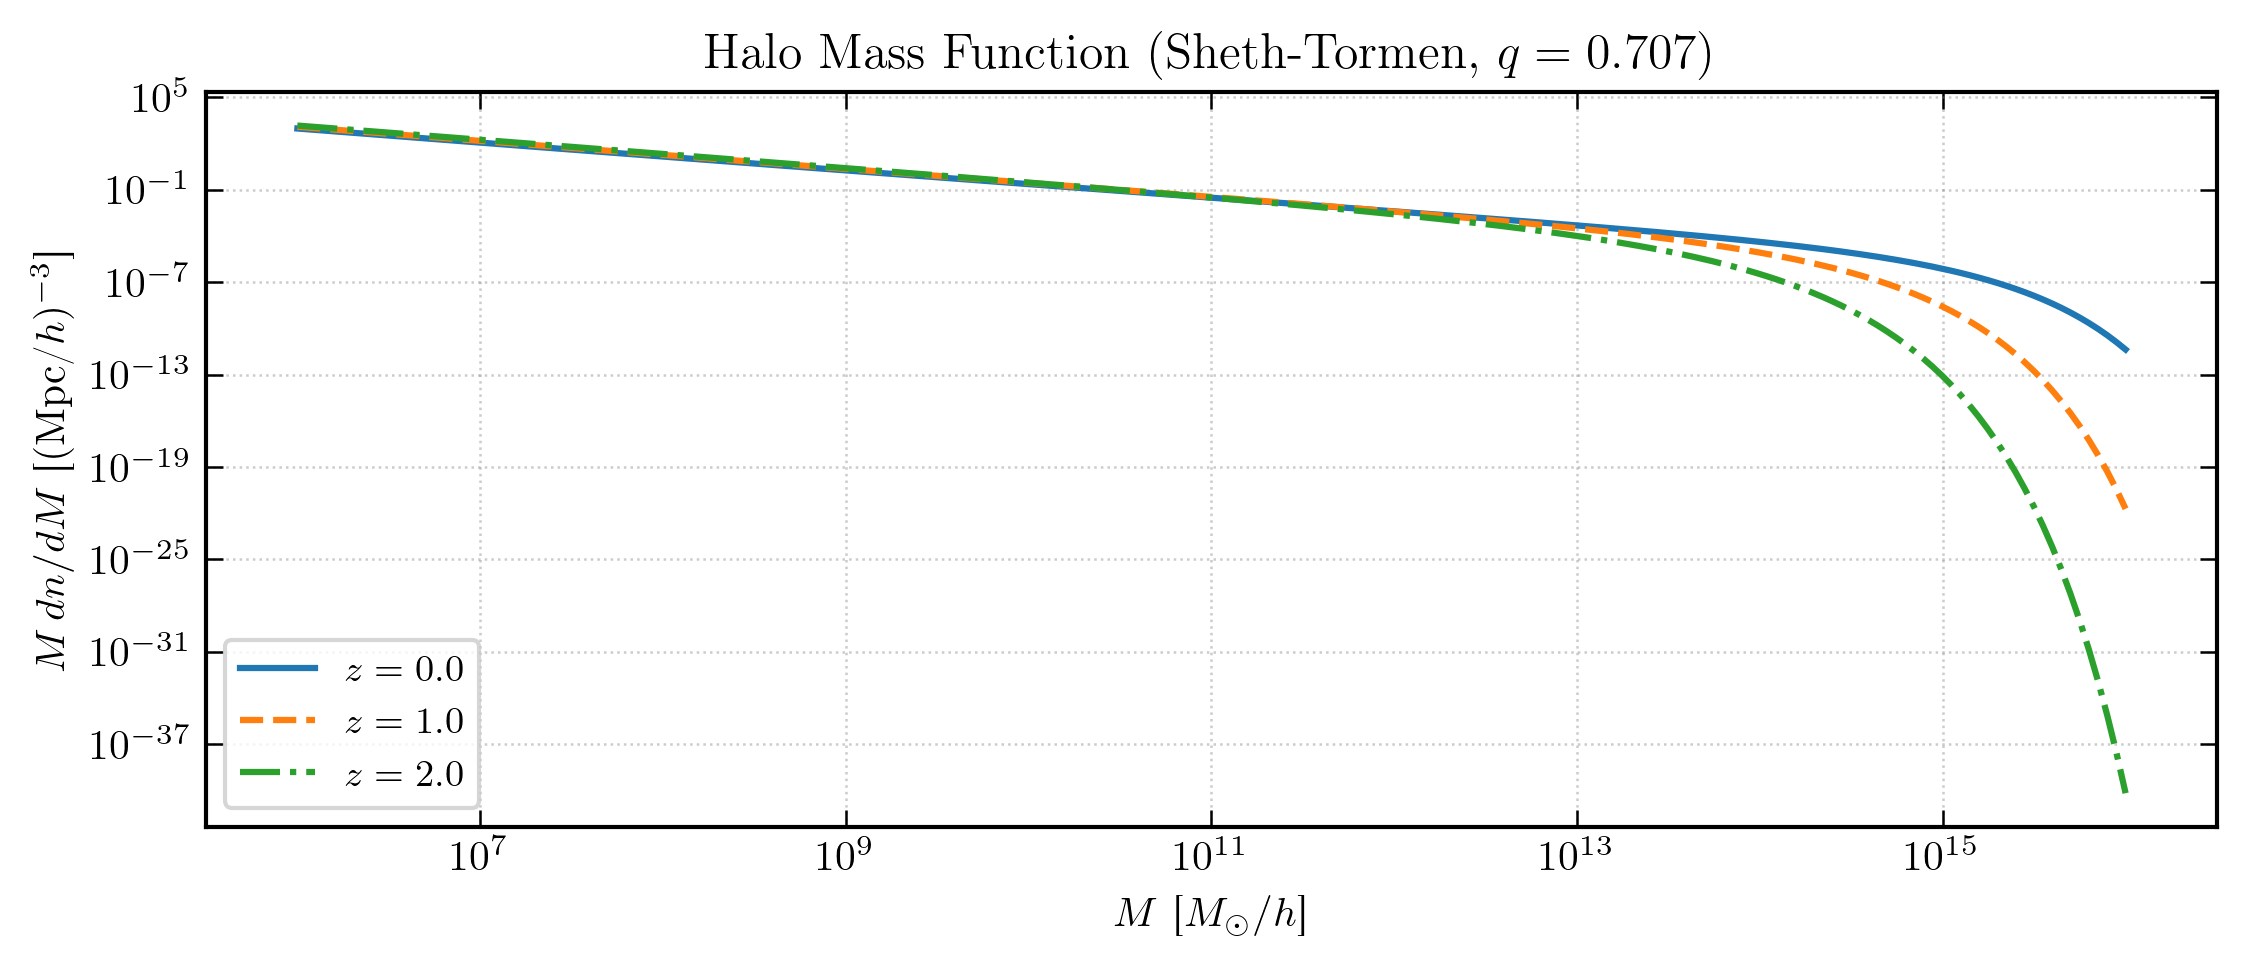

In [ ]:
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0.0, '-'), (1.0, '--'), (2.0, '-.')]:
    dn_dM = np.array([hm.dndM(M, z) for M in M_arr])
    ax.loglog(M_arr, M_arr * dn_dM, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$M$ [$M_\odot/h$]'); ax.set_ylabel(r'$M\,dn/dM$ [(Mpc/$h$)$^{-3}$]')
ax.set_title('Halo Mass Function (Sheth-Tormen, $q=0.707$)')
ax.legend(); fig.tight_layout()

## 5. Halo Bias $b(M,z)$ — Sheth, Mo & Tormen (2001)

$$b(M,z) = 1 + \frac{q\nu^2 - 1}{\delta_c} + \frac{2p/\delta_c}{1 + (q\nu^2)^p}$$

Halos are biased tracers of the underlying matter field: rare (high-$\nu$)
halos cluster more strongly than the matter. $b\to 1$ near $M_*$ (the
$\nu=1$ scale) and rises steeply at high mass. Used in every 2-halo term.

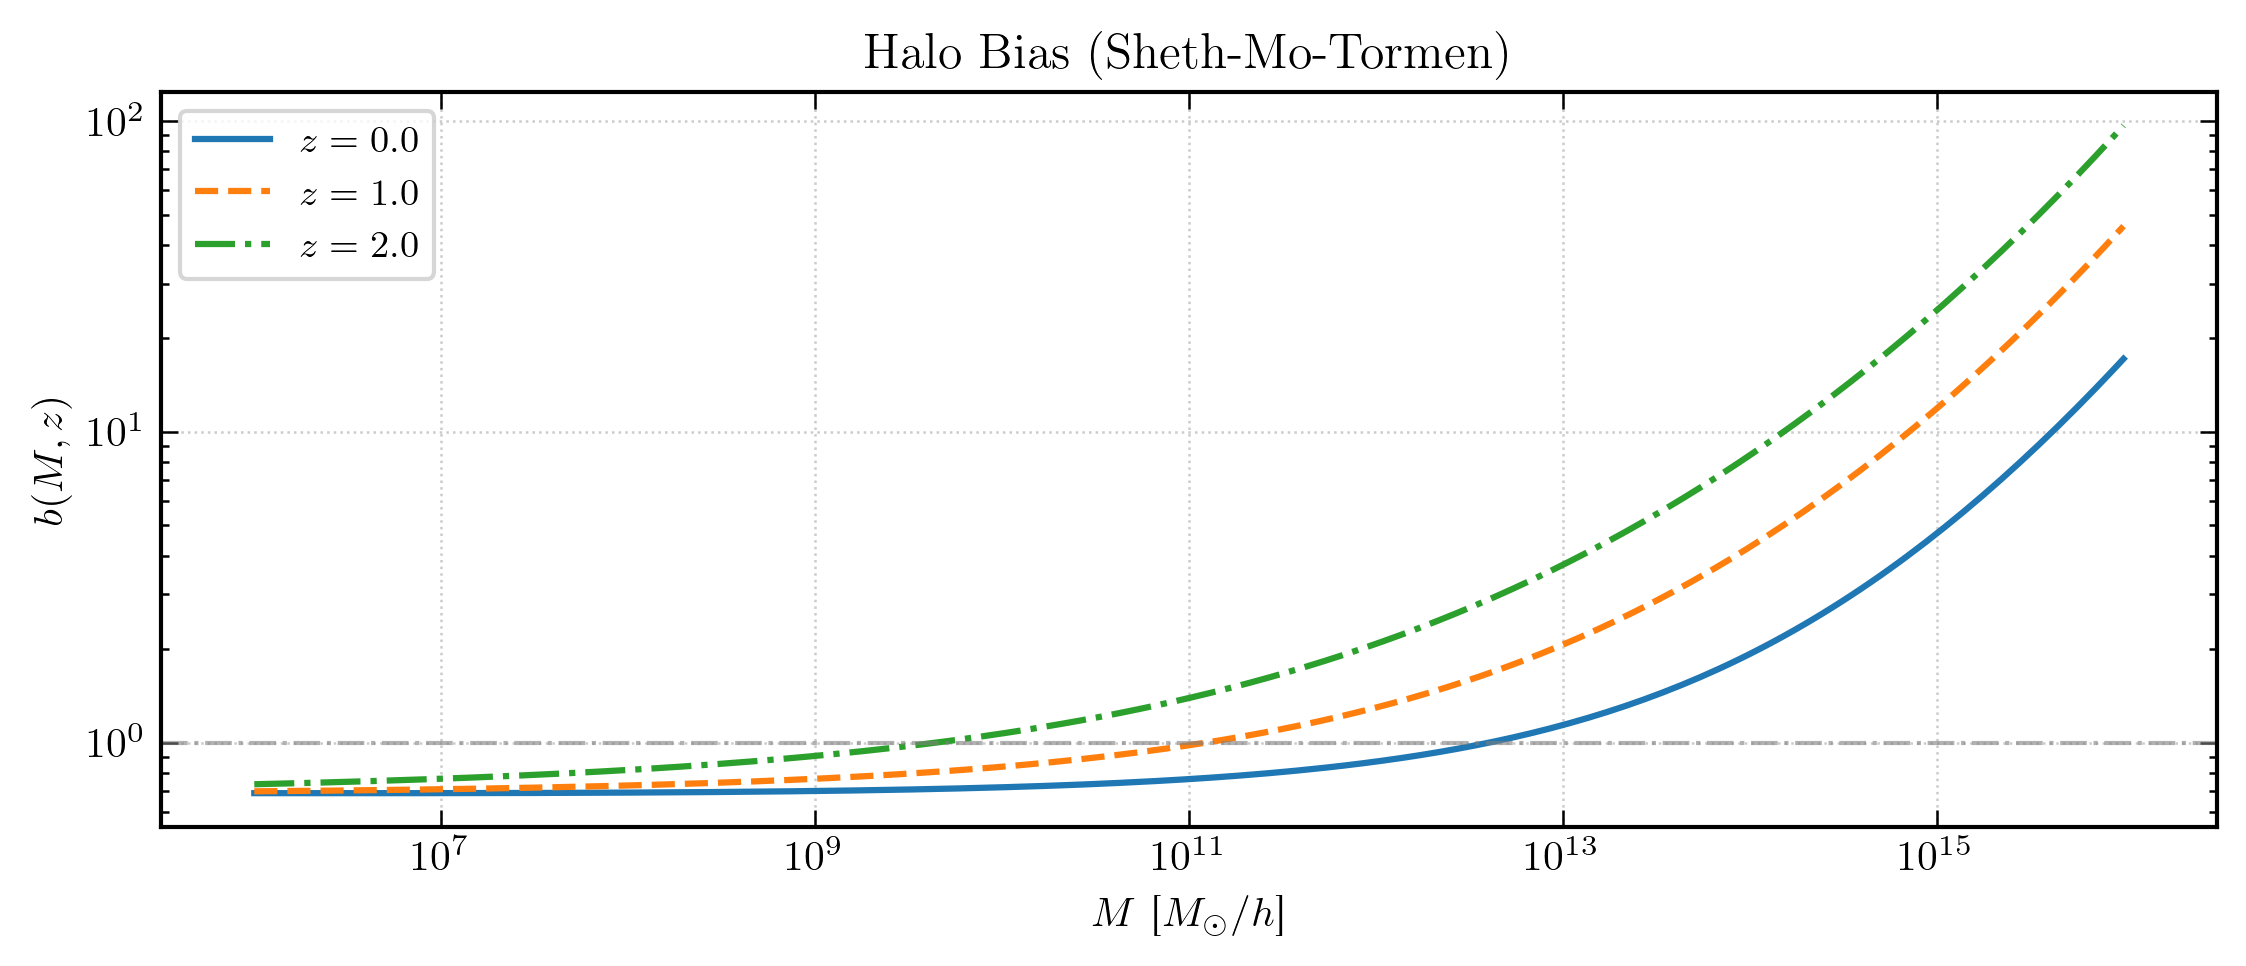

In [ ]:
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0.0, '-'), (1.0, '--'), (2.0, '-.')]:
    b = np.array([hm.bias(M, z) for M in M_arr])
    ax.loglog(M_arr, b, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.axhline(1.0, **sty.GUIDE_STYLE)
ax.set_xlabel(r'$M$ [$M_\odot/h$]'); ax.set_ylabel(r'$b(M,z)$')
ax.set_title('Halo Bias (Sheth-Mo-Tormen)')
ax.legend(); fig.tight_layout()

## 6. Virial Overdensity $\Delta_\mathrm{vir}(z)$ — Bryan & Norman (1998)

$$\Delta_\mathrm{vir}(z) = 18\pi^2 + 82\,x - 39\,x^2, \qquad x = \Omega_m(z) - 1$$

Defines the virial radius via $\bar\rho_\mathrm{vir} = \Delta_\mathrm{vir}(z)\,\rho_\mathrm{crit}(z)$
— i.e. $\Delta_\mathrm{vir}$ here is *relative to the critical density*. At
$z=0$ this gives $\Delta_\mathrm{vir} \approx 103$ for Planck cosmology
($\Omega_m \approx 0.31$), equivalently $\Delta_\mathrm{vir}/\Omega_m \approx 333$ if expressed
relative to the mean matter density. Asymptotes to $18\pi^2 \approx 178$
at high $z$ where $\Omega_m(z)\to 1$ (matter domination, $x\to 0$).

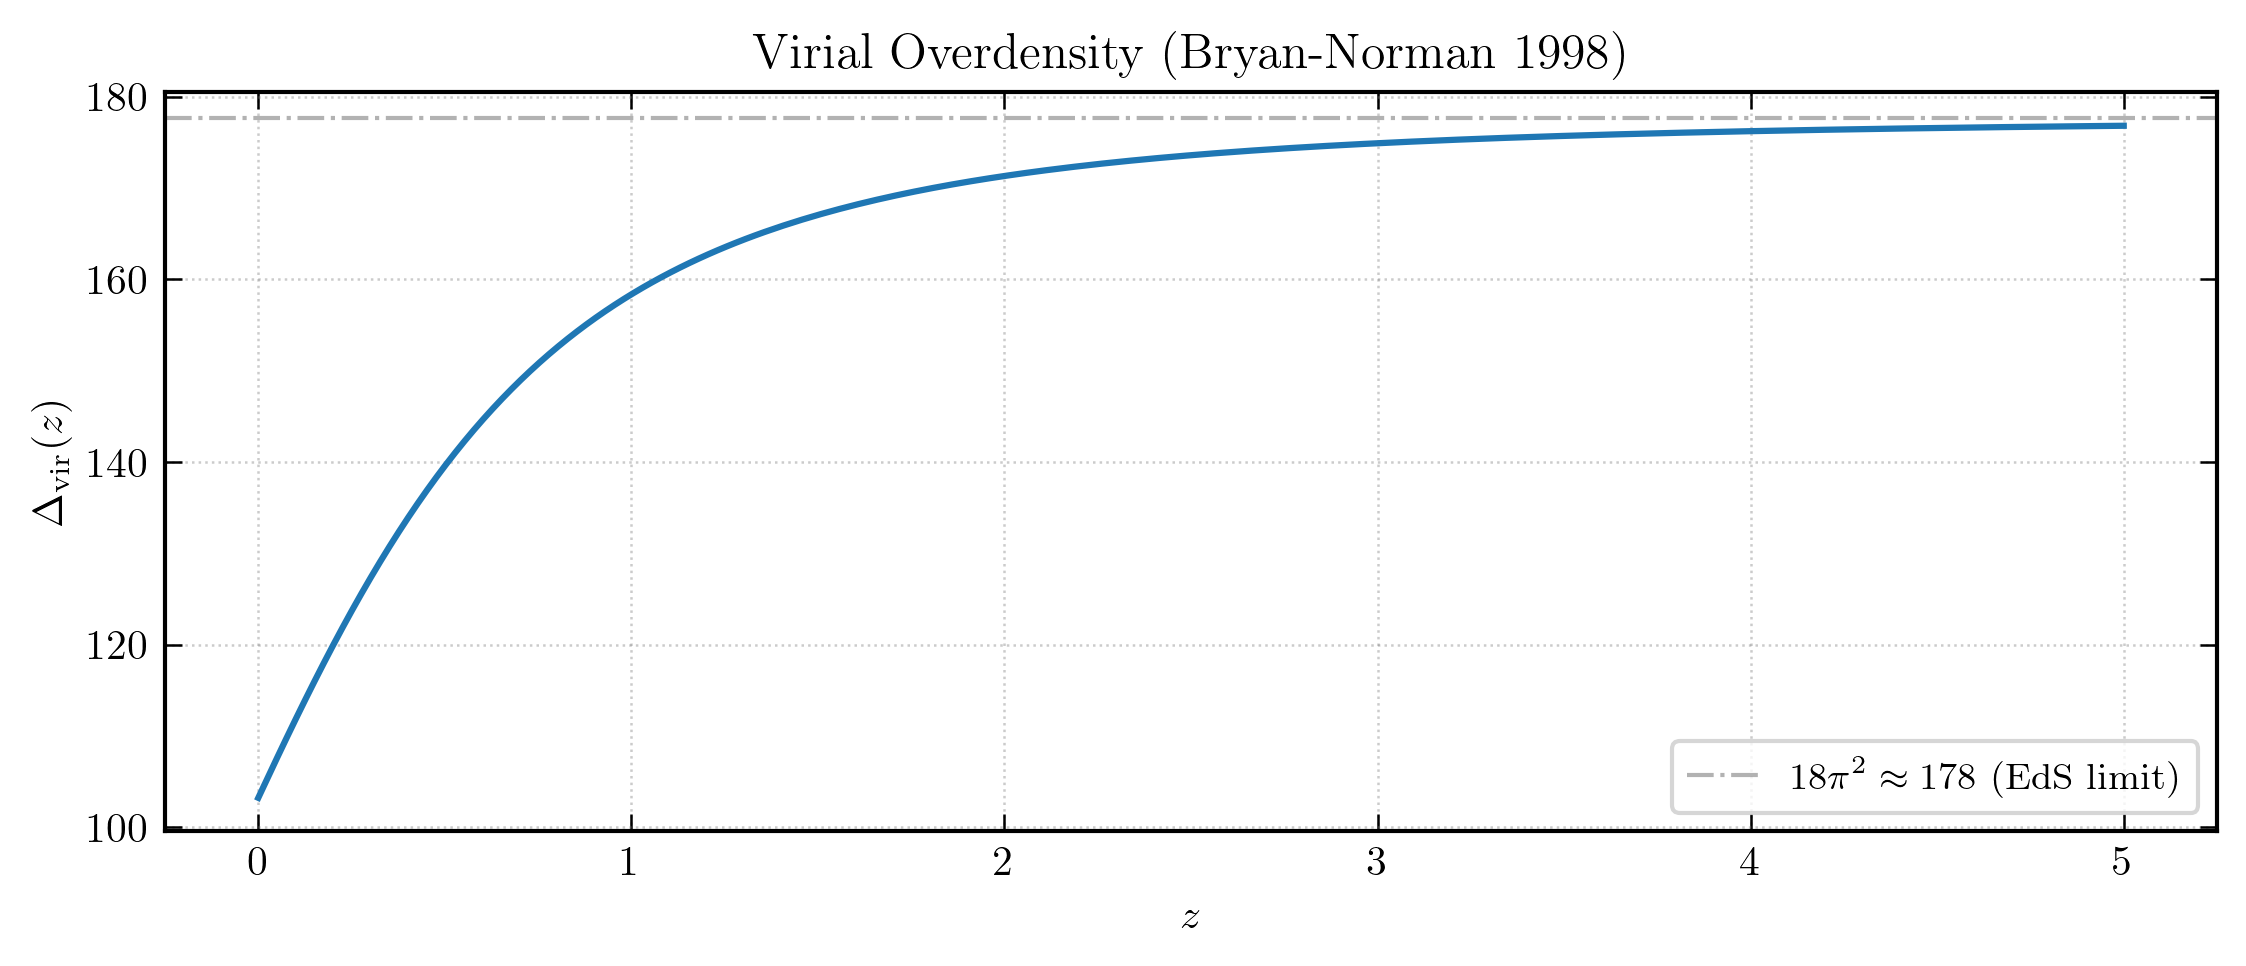

In [ ]:
z_arr_full = np.linspace(0.0, 5.0, 200)
Dvir = np.array([hm.Delta_vir(z) for z in z_arr_full])
fig, ax = sty.textwidth_figure(7)
ax.plot(z_arr_full, Dvir, lw=sty.LW_STANDARD)
ax.axhline(18 * np.pi**2, **sty.GUIDE_STYLE, label=r'$18\pi^2 \approx 178$ (EdS limit)')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$\Delta_\mathrm{vir}(z)$')
ax.set_title('Virial Overdensity (Bryan-Norman 1998)'); ax.legend(); fig.tight_layout()

## 7. Virial Radius $R_\mathrm{vir}(M,z)$

$$R_\mathrm{vir}(M,z) = \left[\frac{3M}{4\pi\,\Delta_\mathrm{vir}(z)\,\rho_\mathrm{crit}(z)}\right]^{1/3}$$

Inverts the §6 definition $\bar\rho_\mathrm{vir} = \Delta_\mathrm{vir}(z)\,\rho_\mathrm{crit}(z)$
with $\rho_\mathrm{crit}(z) = \rho_{\mathrm{crit},0}\,E^2(z)$. This is the
**proper-coordinate** virial radius (in $\mathrm{Mpc}/h$); to express it
in comoving coordinates multiply by $(1+z)$. Combined with $c_\mathrm{vir}$
(or $c_\mathrm{HI}$) it gives the scale radius $r_s = R_\mathrm{vir}/c$.

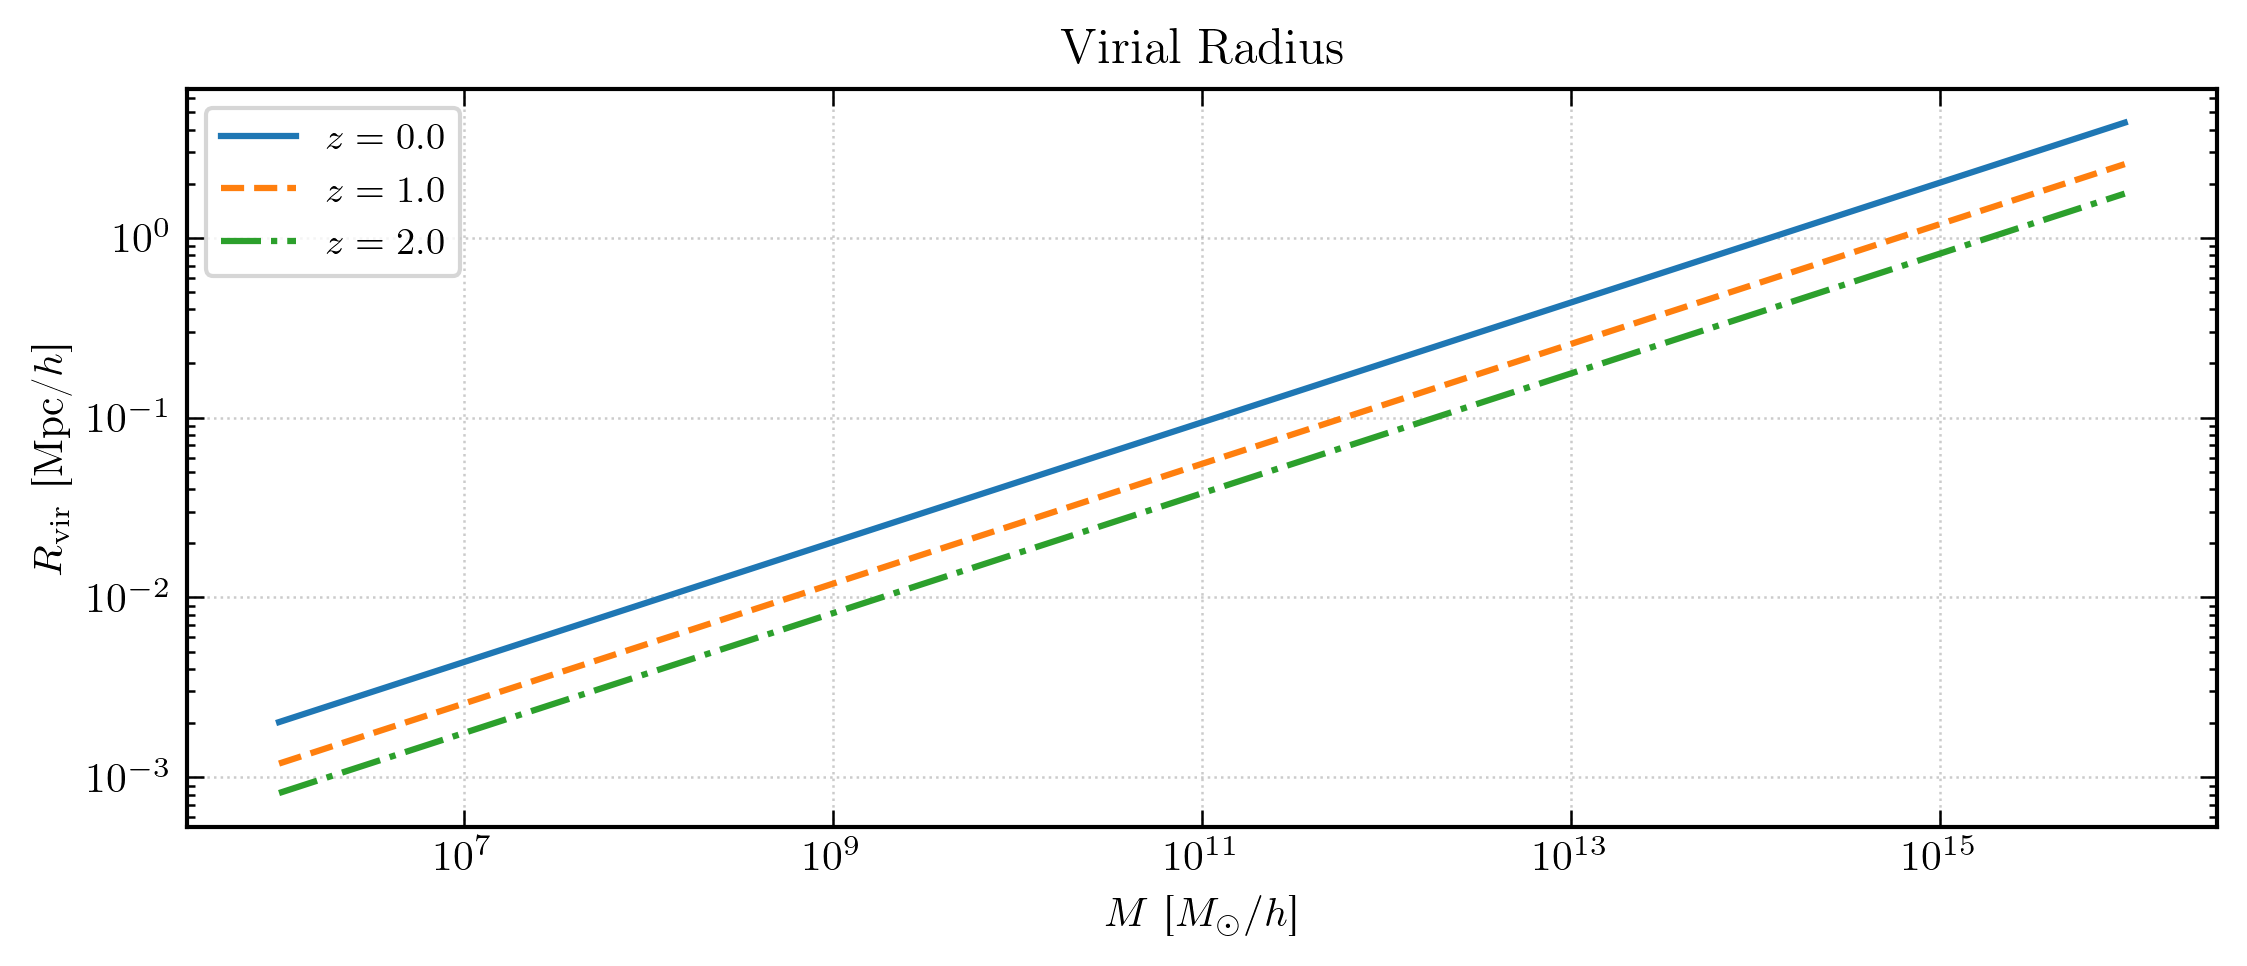

In [ ]:
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0.0, '-'), (1.0, '--'), (2.0, '-.')]:
    Rv = np.array([hm.R_vir(M, z) for M in M_arr])
    ax.loglog(M_arr, Rv, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$M$ [$M_\odot/h$]'); ax.set_ylabel(r'$R_\mathrm{vir}$ [Mpc/$h$]')
ax.set_title('Virial Radius'); ax.legend(); fig.tight_layout()

## 8. DM Concentration $c_\mathrm{vir}(M,z)$ — Correa et al. (2015)

$$\log_{10} c_\mathrm{vir} = \alpha + \beta\,\log_{10}(M/M_\odot)\,[1 + \gamma\,(\log_{10} M)^2]$$

Planck Appendix B1 low-redshift fit (**D2**: thesis used different
cosmology coefficients). Massive halos are less concentrated; concentration
drops with $z$ because halos that exist at high $z$ are necessarily young.
The HI concentration $c_\mathrm{HI}$ is much higher (∼100$\times$) because
neutral gas is dissipative — see `01_hi_model.ipynb` §5.

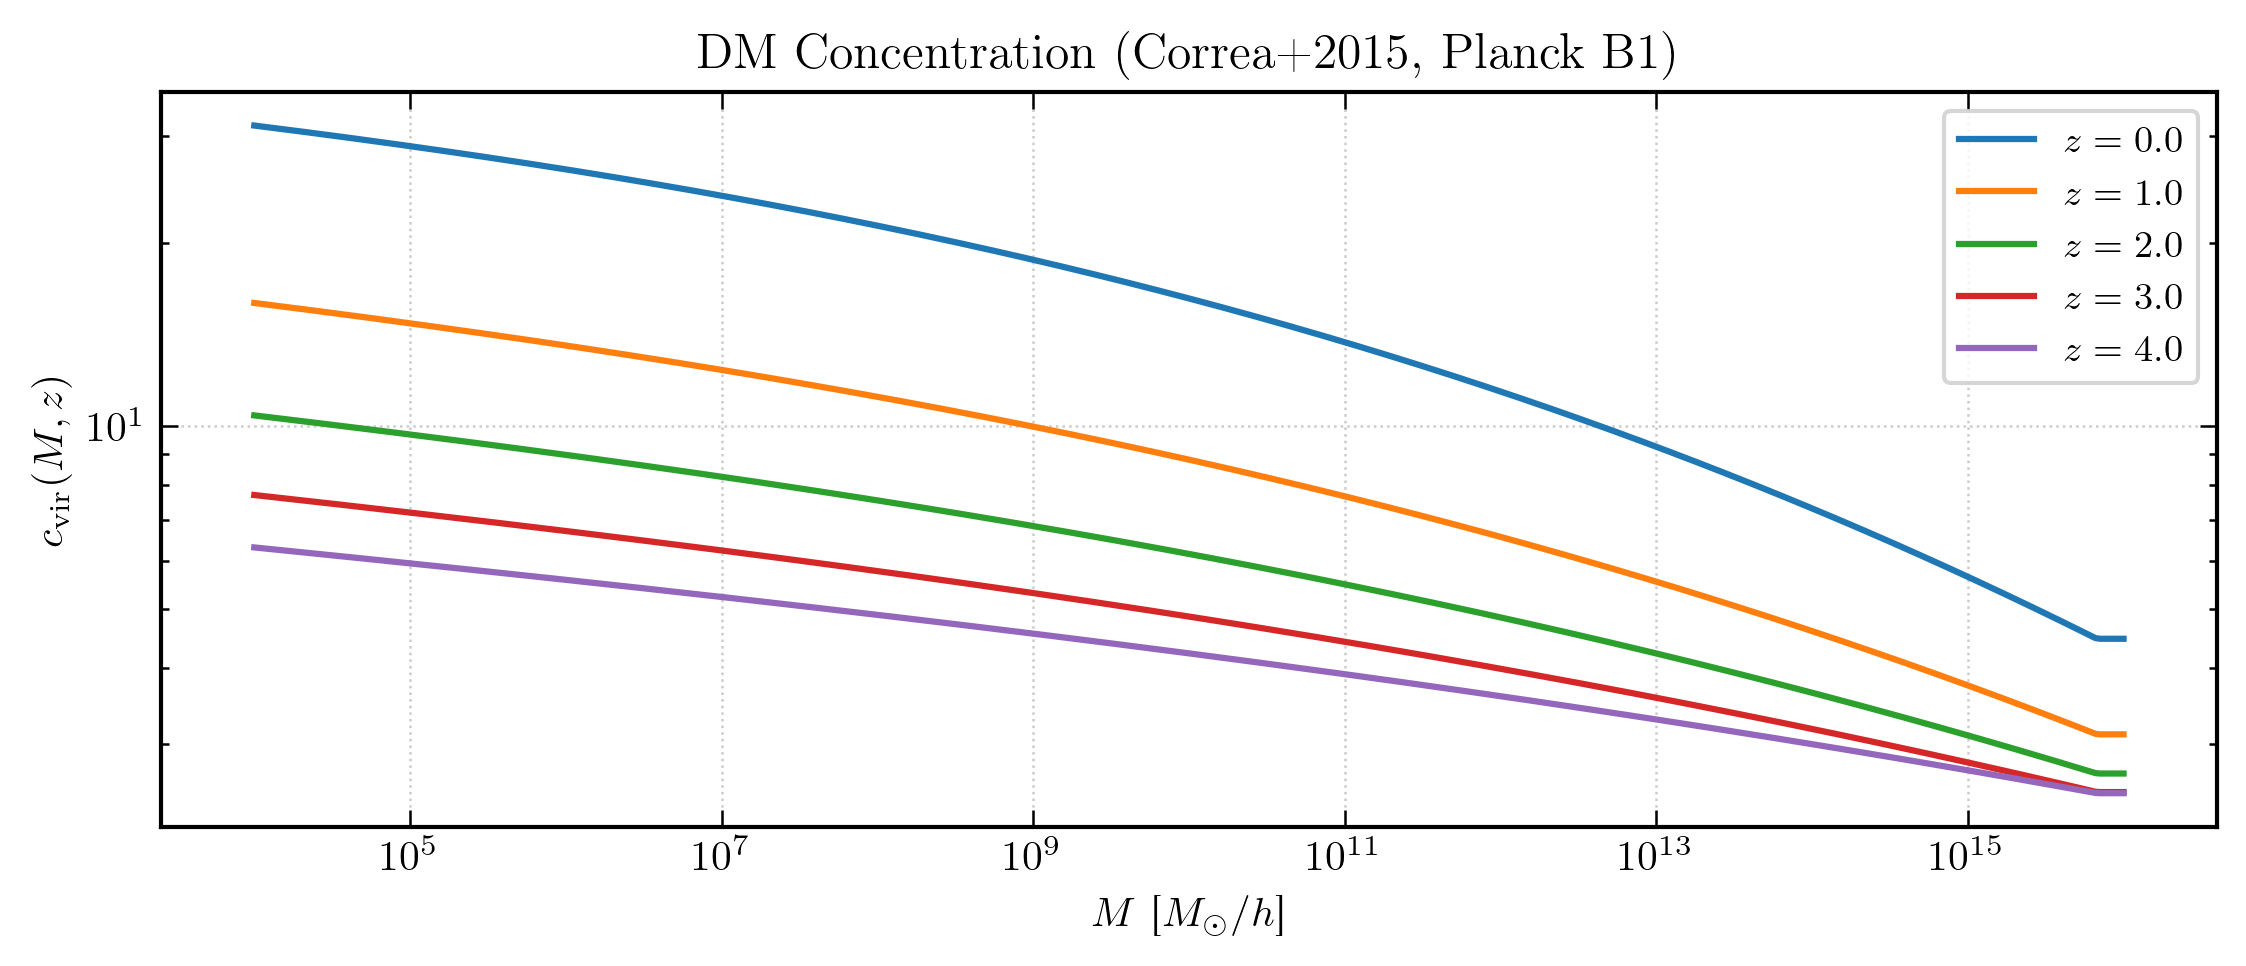

In [ ]:
M_conc = np.logspace(4, 16, 400)
fig, ax = sty.textwidth_figure(7)
for z, color in [(0.0, 'C0'), (1.0, 'C1'), (2.0, 'C2'), (3.0, 'C3'), (4.0, 'C4')]:
    c = np.array([hm.concentration(M, z) for M in M_conc])
    ax.loglog(M_conc, c, color=color, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$M$ [$M_\odot/h$]'); ax.set_ylabel(r'$c_\mathrm{vir}(M,z)$')
ax.set_title('DM Concentration (Correa+2015, Planck B1)')
ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 9. NFW Profile Fourier Transform $\tilde u_\mathrm{NFW}(k\mid M,z)$

$$\rho_\mathrm{NFW}(r) = \frac{\rho_s}{(r/r_s)(1 + r/r_s)^2}, \qquad
\rho_s = \frac{M}{4\pi r_s^3\,\mu(c)}, \quad \mu(c) = \ln(1+c) - c/(1+c)$$

$$\tilde u_\mathrm{NFW}(k\mid M) = \frac{4\pi}{M}\int_0^{R_\mathrm{vir}} r^2\,\rho_\mathrm{NFW}(r)\,\frac{\sin kr}{kr}\,dr$$

Closed form via sine/cosine integrals. $\tilde u_\mathrm{NFW}\to 1$ at
$k\to 0$ (large scales: halo is point-like) and falls off as the profile is
resolved at $k\gtrsim 1/r_s$. This is the DM analogue of $\tilde u_\mathrm{HI}$
in `01_hi_model.ipynb` §6.

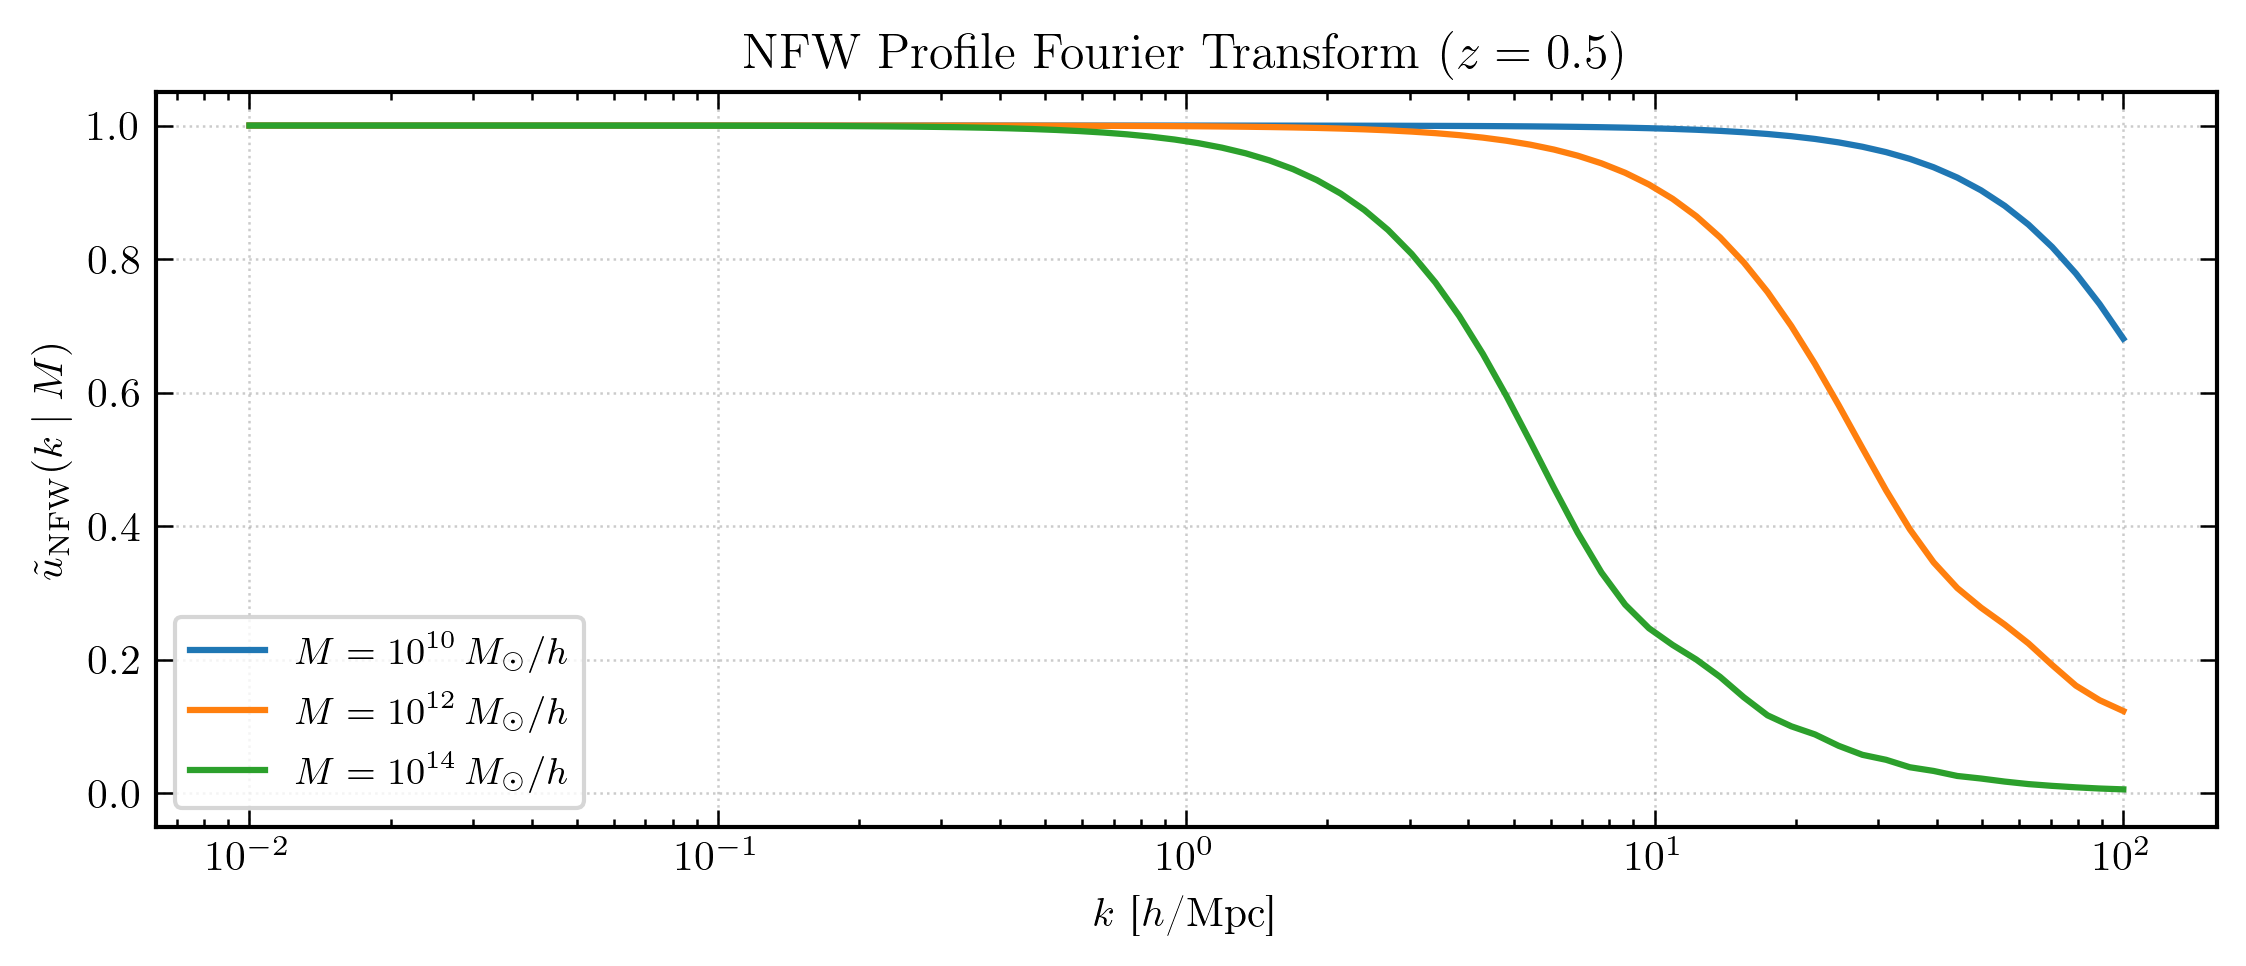

In [ ]:
k_u = np.logspace(-2, 2, 80)
fig, ax = sty.textwidth_figure(7)
z = 0.5
for M, color in [(1e10, 'C0'), (1e12, 'C1'), (1e14, 'C2')]:
    u = hm.u_nfw(k_u, M, z)
    ax.semilogx(k_u, u, color=color, lw=sty.LW_STANDARD,
                label=rf'$M=10^{{{int(np.log10(M))}}}\,M_\odot/h$')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$\tilde u_\mathrm{NFW}(k\mid M)$')
ax.set_title(f'NFW Profile Fourier Transform ($z={z}$)')
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 10. Sanity Checks

Two integral identities the halo model should satisfy at $z=0$:

- $\displaystyle\int dM\,M\,\frac{dn}{dM} = \bar\rho_m^\mathrm{com}$ (mass conservation)
- $\displaystyle\int dM\,M\,b(M)\,\frac{dn}{dM}/\bar\rho_m = 1$ (large-scale bias normalization)

Both should hold to a few percent over a sufficiently wide mass range.

In [ ]:
from scipy.integrate import quad

z = 0.0

def _M2_dndM(lnM):
    M = np.exp(lnM)
    return M * M * hm.dndM(M, z)  # extra M from dM = M d(lnM)

def _M2_b_dndM(lnM):
    M = np.exp(lnM)
    return M * M * hm.bias(M, z) * hm.dndM(M, z)

ln_lo, ln_hi = np.log(1e2), np.log(1e17)
rho_check, rho_err = quad(_M2_dndM, ln_lo, ln_hi, limit=200, epsrel=1e-6)
bias_int, bias_err = quad(_M2_b_dndM, ln_lo, ln_hi, limit=200, epsrel=1e-6)
bias_check = bias_int / cfg.RHO_BAR

print(f'  rho_m (mass integral) = {rho_check:.4e}  (err {rho_err:.1e})  M_sun/h / (Mpc/h)^3')
print(f'  rho_m (config)        = {cfg.RHO_BAR:.4e}  M_sun/h / (Mpc/h)^3')
print(f'  ratio                 = {rho_check / cfg.RHO_BAR:.4f}')
print()
print(f'  <b> (bias integral)   = {bias_check:.4f}  (err {bias_err / cfg.RHO_BAR:.1e})  (should be ~1)')